In [1]:
#|default_exp app

Dogs v Cats

In [2]:
#|export

from fastai.vision.all import *
import gradio as gr

def is_cat(x): return x[0].isupper()

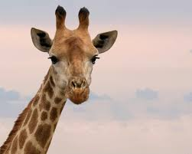

In [10]:
#im = PILImage.create('cat.jpg')
im = PILImage.create('gif.jpg')
im.thumbnail((192,192))
im

In [4]:
#|export
learn = load_learner('model.pkl')

/home/nradhakrishnan/miniforge3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [11]:
%time learn.predict(im)

CPU times: user 340 ms, sys: 0 ns, total: 340 ms
Wall time: 57.7 ms


('False', tensor(0), tensor([0.6327, 0.3673]))

In [6]:
#|export
categories = ('Dog','Cat','Dunno')

def classify_image(img):
    pred,idx,probs = learn.predict(img)
    return dict(zip(categories, map(float,probs)))
    

In [12]:
classify_image(im)

{'Dog': 0.6327236294746399, 'Cat': 0.3672763407230377}

In [8]:
#|export
# image = gr.inputs.Image(shape=(192,192))
#image = gr.Image(192,192)
#label = gr.outputs.Label()
#image = PILImage.Image()
examples = ['dog.jpg','cat.jpg','dunno.jpg']

intf = gr.Interface(fn=classify_image, inputs=gr.Image(type="pil"), outputs=gr.Label(), examples=examples)
intf.launch(inline=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


SyntaxError: invalid syntax (2562660340.py, line 1)